We are building a Sequential Workflow using LangGraph and Google Gemini. Our objective is to create a Sequential System for classifying the financial credit risk

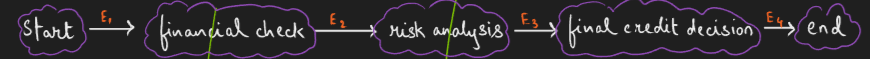

In [1]:
!pip install langgraph langchain langchain-google-genai google-generativeai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 2.2 MB/s eta 0:00:00


In [2]:
#Installing the required dependencies
from langgraph.graph import StateGraph, START, END #START and END are dummy nodes in LangGraph
from typing import TypedDict #this is a special type of Dict where we specify the datatype also
from langchain_google_genai import ChatGoogleGenerativeAI #for getting a response from the LLM
from langchain_core.tools import tool
from IPython.display import Image #visualize the workflow created using LangGraph

In [3]:
#Configuring the Gemini API
import os
os.environ["GOOGLE_API_KEY"]="API"

In [4]:
#Initializing the Gemini LLM
llm=ChatGoogleGenerativeAI(
    model='gemini-2.5-flash'
)

In [5]:
class CreditState(TypedDict):

  #inputs from the User
  credit_score:int
  income:float
  existing_debt:float

  #outputs from the Workflow
  financial_status:str
  risk_decision:str
  final_decision:str

With respect to Tools, we should always have the following 3 things defined in a Tool

- Name of the Tool
- Description of the Tool
- Input schema of the Tool

In [6]:
#Creating a Tool which does financial verification
@tool
def financial_verification_tool(income:float,debt:float)->str:
  """This tool, it analyzes an individual's financial status based on income and debt"""
  debt_ratio=debt/income

  if debt_ratio>0.5:
    return "High Debt Exposure"

  return "Financially Stable"

In [8]:
#Creating a Node to do a Financial Health Check
def Financial_Health_Check(state:CreditState)->CreditState:
  result = financial_verification_tool.invoke({
      "income":state['income'],
      "debt":state['existing_debt']
  })
  state['financial_status']=result
  return state

In [9]:
#Creating a Node for performing Risk Analysis
def risk_analysis(state:CreditState)->CreditState:
  prompt=f"""
  Analyze this loan applicant.

  Credit Score: {state['credit_score']}
  Financial Status: {state['financial_status']}

  Return only:
  APPROVING
  REVIEWING
  REJECTING
  """

  response=llm.invoke(prompt)
  state['risk_decision']=response.content.strip()
  return state

In [10]:
def final_credit_decision(state:CreditState)->CreditState:
  state['final_decision']=state['risk_decision']
  return state

In [11]:
#Compiling the nodes and edges to the Workflow
graph=StateGraph(CreditState)

graph.add_node("financial_health_check",Financial_Health_Check)
graph.add_node("risk_analysis",risk_analysis)
graph.add_node("final_credit_decision",final_credit_decision)


graph.set_entry_point("financial_health_check")

graph.add_edge("financial_health_check","risk_analysis")
graph.add_edge("risk_analysis","final_credit_decision")
graph.add_edge("final_credit_decision",END)

workflow=graph.compile()


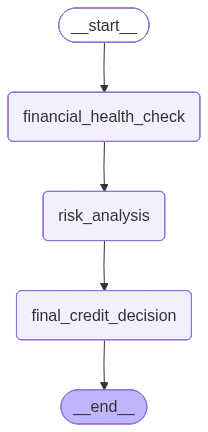

In [12]:
workflow

In [15]:
initial_state:CreditState={
    "credit_score":480,
    "income":12000,
    "existing_debt":400000
}

print(workflow.invoke(initial_state))

{'credit_score': 480, 'income': 12000, 'existing_debt': 400000, 'financial_status': 'High Debt Exposure', 'risk_decision': 'REJECTING', 'final_decision': 'REJECTING'}


Task:

Healthcare Risk Triage Workflow:
Evaluate the patient details (vitals) and then classify
- patient needs doctor review | routine monitoring etc.